Nom : Khadijetou Mohamed abe

Filière : GLCC

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1.CODE SCRATCH

In [2]:
def sigmoid(z):
    # """
    # La fonction sigmoïde transforme n'importe quelle valeur réelle en une valeur entre 0 et 1.
    # On l'interprète comme la probabilité que y=1 sachant X.
    # Formule : σ(z) = 1 / (1 + e^(-z))
    # """
    return 1 / (1 + np.exp(-z))


def model_logistic(X, W):
    # """
    # Modèle logistique de la forme f(x) = σ(X.W)
    # 1. On calcule d'abord la combinaison z = X.W 
    # 2. On passe le résultat dans la fonction sigmoïde pour obtenir une probabilité.
    # Le résultat (y_predict) contient les valeurs entre 0 et 1.
    # """
    # X.dot(W) correspond au produit matriciel z
    z = X.dot(W)
    # On applique la sigmoïde
    return sigmoid(z)
    

def calcul_gradient_logistic(X, y, W, lambda_reg=0.1):
    # """
    # Calcule le gradient de la fonction de coût "log-loss" J(W) = - (1/m) * sum [ y log(y_predict) + (1 - y) log(1 - y_predict) ] .
    # La formule est dérivée de cette fonction de coût:
    # ∇J(W) = (1/m) * X.T * (ŷ - y)
    # où ŷ = σ(X.W)
    # """
    # nombre de lignes de y (m)
    m = len(y)   
    # prédiction du modèle (probabilités entre 0 et 1)
    y_predict = model_logistic(X, W)
    # calcul de l'erreur : différence entre la probabilité prédite et le réel (0 ou 1)
    erreur = y_predict - y
    # '''
    # La formule du gradient est (1 / m) * X.T.dot(erreur)
    # '''
    grad = (1 / m) * X.T.dot(erreur)
    # Dans ma première tentative, j'ai eu du surapprentissage, donc on applique la régularisation
    # régularisation L2 (on ne régularise pas le biais W[0])
    W_reg = W.copy()
    W_reg[0] = 0 # on ne régularise pas le biais (W[0])
    grad = grad + lambda_reg * W_reg  
    return grad

def descente_gradient(X, y, pas=0.1, epsilon=10**-3, k_max=1000, lambda_reg=0.1):
    # On ajoute la colonne de biais (des 1) à la matrice X
    X_b = ajouter_biais(X) 
    # initialisation de W à 0 
    W = np.zeros((X_b.shape[1], 1))
    # initialisation du nombre d’itérations
    k = 0
    # calcul du gradient initial
    grad = calcul_gradient_logistic(X_b, y, W, lambda_reg)   
    
    # '''
    # Arrêt quand le gradient devient très petit (convergence) ou si on dépasse k_max
    while np.linalg.norm(grad) > epsilon and k < k_max:
        # mise à jour de W avec le pas d’apprentissage
        W = W - pas * grad
        # recalcul du gradient après la mise à jour
        grad = calcul_gradient_logistic(X_b, y, W, lambda_reg) 
        # incrémentation du compteur d’itérations
        k += 1
    # pour debug : si on atteint k_max sans convergence
    print("itération k=",k)
    return W

# helpers
def ajouter_biais(X):
    # """Ajoute automatiquement la colonne de 1 à la matrice X."""
    # X.shape[0] = nombre de lignes
    # np.ones((X.shape[0], 1)) crée une colonne de 1
    return np.hstack((np.ones((X.shape[0], 1)), X))
    
# Modifiée pour la classification
def predict_logistic(X, W, seuil=0.5):
    # """
    # Retourne la classe finale (0 ou 1) en fonction d'un seuil.
    # """
    # Ajoute le biais à X
    X_b = ajouter_biais(X)
    # Calcule la probabilité avec le modèle logistique
    probabilites = model_logistic(X_b, W)
    # Renvoie 1 si la probabilité est >= au seuil (0.5), sinon 0
    return (probabilites >= seuil).astype(int)



## a. DATASET

In [3]:
# X : âge des patients
# reshape pour obtenir une forme matricielle (14 lignes, 1 colonne)
X_age_original = np.array([22, 28, 32, 35, 40, 44, 48, 52, 56, 60, 65, 70, 75, 80]).reshape(-1, 1)

# Y : maladie (0 = sain, 1 = malade)
y_data_logistic = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]).reshape(-1, 1)

# Création du scaler (outil de normalisation)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit_transform calcule la moyenne (μ) et l’écart-type (σ) et applique la normalisation
# Formule :
# x_norm = (x - μ) / σ
#
# Ici on transforme les âges réels en version normalisée
X_data_logistic = scaler.fit_transform(X_age_original)

## b. Exécution du code scratch

In [4]:
# On entraîne notre modèle scratch sur des données normalisées.
# Grâce à la normalisation, l’algorithme converge beaucoup plus vite.
W_logistic = descente_gradient(X_data_logistic, y_data_logistic, pas=0.1, k_max=5000, lambda_reg=0.0069)

# On obtient les prédictions finales (0 ou 1)
predictions_scratch_logistic = predict_logistic(X_data_logistic, W_logistic)

print("Poids W trouvés par notre code scratch (w0, w1) :")
print(W_logistic.T)

itération k= 1916
Poids W trouvés par notre code scratch (w0, w1) :
[[1.07303686 4.11093461]]


## c. Code sklearn

In [5]:
# import de la classe
from sklearn.linear_model import LogisticRegression

# On crée un objet en initialisant le constructeur de la classe LogisticRegression
# C est le paramètre de régularisation pour la régression logistique dans sklearn
modele_sklearn_logistic = LogisticRegression(C=10)

# On entraîne le modèle sur les mêmes données
# .ravel() est utilisé pour transformer y de (14, 1) à (14,) pour sklearn
modele_sklearn_logistic.fit(X_data_logistic, y_data_logistic.ravel())

# On obtient les prédictions (0 ou 1) de sklearn
predictions_sklearn_logistic = modele_sklearn_logistic.predict(X_data_logistic)

## d. Comparaison et graphiques (scratch/sklearn)

Comparaison des paramètres W
Scratch : [[1.07303686 4.11093461]] | Sklearn : [1.07759548] [[4.11161008]]


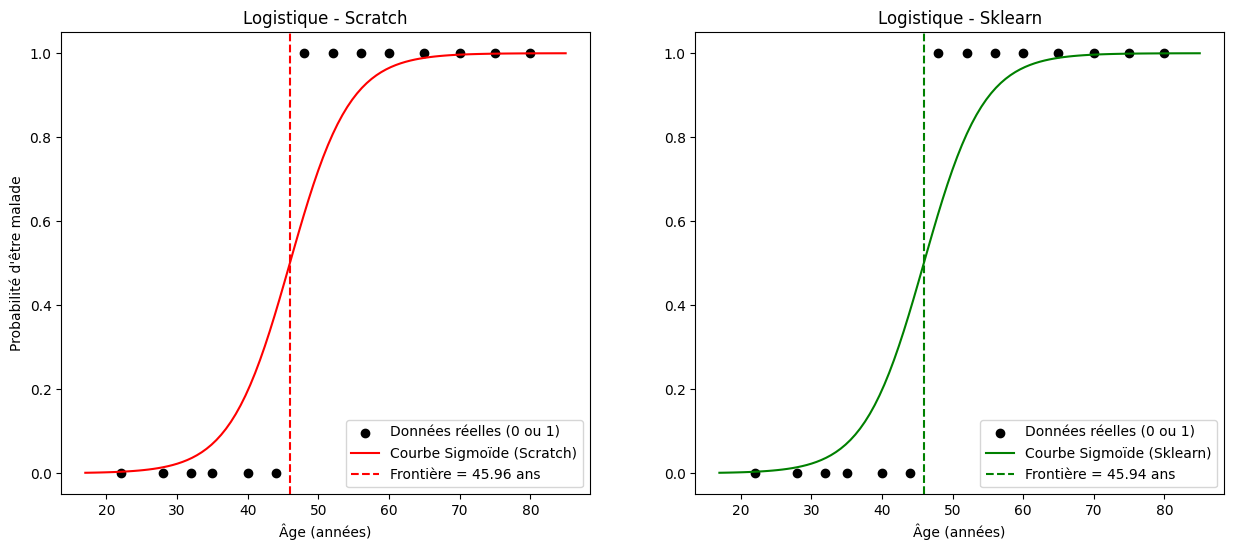

In [6]:
print("Comparaison des paramètres W")
# .intercept_ contient w0 (biais) et .coef_ contient w1, w2, f_)...
print("Scratch :", W_logistic.T, "| Sklearn :", modele_sklearn_logistic.intercept_, modele_sklearn_logistic.coef_)

# Axe X basé sur les âges réels pour un affichage lisible
# On prend min et max des âges réels et on élargit un peu la plage avec 100 points
X_range = np.linspace(X_age_original.min() - 5, X_age_original.max() + 5, 100).reshape(-1, 1)
# Normalisation avec le scaler déjà entraîné car le modèle a été entraîné sur des données normalisées
X_range_scaled = scaler.transform(X_range)


# PRÉDICTIONS DES DEUX MODÈLES
# Calcul des probabilités (sigmoïde) pour la courbe scratch (en utilisant les données normalisées)
X_range_biais = ajouter_biais(X_range_scaled)
probabilites_scratch = model_logistic(X_range_biais, W_logistic)
# Calcul des probabilités pour la courbe sklearn
# On prend seulement la probabilité de la classe 1 (malade = 1)
probabilites_sklearn = modele_sklearn_logistic.predict_proba(X_range_scaled)[:, 1]

#  Affichage des graphiques
plt.figure(figsize=(15, 6))

# Graphique Scratch
plt.subplot(1, 2, 1)
# On trace les points Points réels (âge et malade ou non)
plt.scatter(X_age_original, y_data_logistic, color='black', label='Données réelles (0 ou 1)')
# Courbe de probabilité
plt.plot(X_range, probabilites_scratch, 'r', label='Courbe Sigmoïde (Scratch)')
# Calcul de la frontière (là où probabilité = 0.5, donc z = 0)
# Donc z = 0 => on résout W0 + W1*x = 0
# scaler.inverse_transform = remet la valeur normalisée dans l’échelle réelle
# [[...]] = format 2D requis par sklearn (1 ligne, 1 feature)
# .item() = transforme array numpy item en valeur python
# [0][0] = extraction finale :première ligne, première colonne
frontiere_age_scratch = scaler.inverse_transform( [[(-W_logistic[0] / W_logistic[1]).item()]])[0][0]
plt.axvline(x=frontiere_age_scratch, color='r', linestyle='--', label=f'Frontière = {frontiere_age_scratch:.2f} ans')
plt.title('Logistique - Scratch')
plt.ylabel('Probabilité d\'être malade')
plt.xlabel('Âge (années)')
plt.legend()


# Graphique Sklearn
plt.subplot(1, 2, 2)
plt.scatter(X_age_original, y_data_logistic, color='black', label='Données réelles (0 ou 1)')
plt.plot(X_range, probabilites_sklearn, 'g', label='Courbe Sigmoïde (Sklearn)')
# Calcul de la frontière pour sklearn
frontiere_age_sklearn = scaler.inverse_transform([[(-modele_sklearn_logistic.intercept_ / modele_sklearn_logistic.coef_).item()]])[0][0]
plt.axvline(x=frontiere_age_sklearn, color='g', linestyle='--', label=f'Frontière = {frontiere_age_sklearn:.2f} ans')
plt.title('Logistique - Sklearn')
plt.xlabel('Âge (années)')
plt.legend()

plt.show()